# Урок 7.1. Ранняя остановка и число итераций

**Интерактивная версия:** `lessons/lesson_7_1/web/index.html`

1. Ранняя остановка своими руками.
2. Шум валидации: разные разбиения дают разные лучшие итерации.
3. Число деревьев кросс-валидацией и финальная модель.
4. Ранняя остановка в XGBoost, LightGBM, CatBoost.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from gbcourse import datasets, GBRegressor
from gbcourse.metrics import mse
from gbcourse.plotting import use_course_style

use_course_style()

X, y = datasets.regression_1d(kind="wave", n=600, noise=0.6, seed=72)
X_test, y_test = datasets.regression_1d(kind="wave", n=3000, noise=0.6, seed=73)

## 1. Своими руками

In [2]:
def early_stop(curve, patience):
    best = 0
    for m in range(1, len(curve)):
        if curve[m] < curve[best]:
            best = m
        elif m - best >= patience:
            return best, m
    return best, len(curve) - 1


X_tr, X_val, y_tr, y_val = datasets.train_test_split(X, y, test_size=0.3, seed=0)
m = GBRegressor(n_estimators=800, learning_rate=0.1, max_depth=3).fit(X_tr, y_tr, eval_set=(X_val, y_val))
for p in (5, 20, 50, 200):
    best, stop = early_stop(m.history_["eval"], p)
    print(f"patience {p:3d}: остановка на {stop:3d}, лучшая {best:3d}, ½MSE теста {mse(y_test, m.predict(X_test, n_iter=best)) / 2:.4f}")

patience   5: остановка на  46, лучшая  41, ½MSE теста 0.1967
patience  20: остановка на  61, лучшая  41, ½MSE теста 0.1967
patience  50: остановка на  91, лучшая  41, ½MSE теста 0.1967
patience 200: остановка на 241, лучшая  41, ½MSE теста 0.1967


## 2. Шум валидации

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


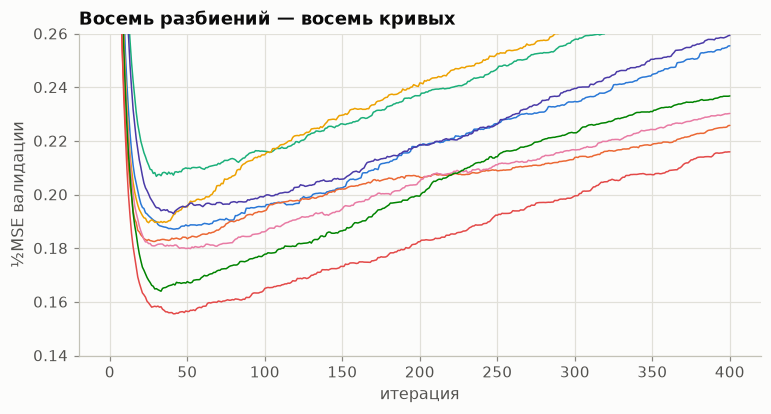

лучшие итерации по разбиениям: [41, 29, 30, 25, 52, 33, 41, 41]


In [3]:
bests = []
fig, ax = plt.subplots(figsize=(8, 3.8))
for split in range(8):
    a, b, c, d = datasets.train_test_split(X, y, test_size=0.3, seed=split)
    mm = GBRegressor(n_estimators=400, learning_rate=0.1, max_depth=3).fit(a, c, eval_set=(b, d))
    bests.append(mm.best_iteration_)
    ax.plot(mm.history_["eval"], lw=1)
ax.set(xlabel="итерация", ylabel="½MSE валидации", ylim=(0.14, 0.26), title="Восемь разбиений — восемь кривых")
plt.show()
print("лучшие итерации по разбиениям:", bests)

## 3. Число деревьев кросс-валидацией и финальная модель

In [4]:
folds = np.array_split(np.random.default_rng(0).permutation(len(y)), 5)
curves = []
for j in range(5):
    tr = np.concatenate([folds[i] for i in range(5) if i != j])
    mm = GBRegressor(n_estimators=400, learning_rate=0.1, max_depth=3).fit(X[tr], y[tr], eval_set=(X[folds[j]], y[folds[j]]))
    curves.append(mm.history_["eval"])
cv_curve = np.mean(curves, axis=0)
M_cv = int(np.argmin(cv_curve))
final = GBRegressor(n_estimators=M_cv, learning_rate=0.1, max_depth=3).fit(X, y)
print(f"число деревьев по CV: {M_cv}; ½MSE финальной модели на тесте {mse(y_test, final.predict(X_test)) / 2:.4f}")

число деревьев по CV: 32; ½MSE финальной модели на тесте 0.1927


## 4. В библиотеках

In [5]:
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

xm = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.05, max_depth=3, early_stopping_rounds=50)
xm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
lm = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.05, num_leaves=8, verbose=-1)
lm.fit(X_tr, y_tr, eval_X=(X_val,), eval_y=(y_val,), callbacks=[lgb.early_stopping(50, verbose=False)])
cm = CatBoostRegressor(iterations=2000, learning_rate=0.05, depth=3, verbose=0, random_seed=0)
cm.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50, use_best_model=True)
for name, it, model in (("XGBoost", xm.best_iteration, xm), ("LightGBM", lm.best_iteration_, lm), ("CatBoost", cm.get_best_iteration(), cm)):
    print(f"{name:8s}: лучшая итерация {it:4d}, ½MSE теста {mse(y_test, model.predict(X_test)) / 2:.4f}")

XGBoost : лучшая итерация  150, ½MSE теста 0.1975
LightGBM: лучшая итерация  155, ½MSE теста 0.1921
CatBoost: лучшая итерация  166, ½MSE теста 0.1863


## Упражнения

1. Для ν = 0.01 найдите минимальное patience, при котором остановка не срабатывает раньше глобального минимума валидации.
2. Сравните ½MSE теста у финальной модели «CV-число деревьев на всех данных» и «ранняя остановка на 70% данных».

Решения: `python lessons/lesson_7_1/exercises/solutions.py`.